# Create an elastic network for 7tx0 (mac1, p43 space group) and find its band structure

Goal: create a real enm and construct its Hessian & band structure

Code mostly lifted from proto-hessian.ipynb and 7tx0-enm.ipynb

Steps:

1. Use Mac1 P43 + ADPr [7TX0](https://www.rcsb.org/structure/7TX0), with two copies in the ASU. Group atoms by chain ID.
2. Pack the unit cell
3. Construct the contact list for the ASU. Keep only contacts between groups (or with other ASUs).
4. Expand to fill unit cell and add node positions
5. Learn how Hessian construction works for rigid bodies (TLS? Projections?)
6. Plot band structure along special directions. Following the TET path in [Setyawan and Curtarolo](https://arxiv.org/pdf/1004.2974), plot Γ-X-M-Γ-Z-R-A-Z|X-R|M-A.
7. Plot DOS from band structure.

In [1]:
#I will use gemmi to parse the PDB file 7tx0.cif.
#I then want to go towards constructing a Hessian for the rigid body ENM with springs organized nicely in a dataframe.
from goodvibes import enm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gemmi
from scipy import sparse

# 1. Assign rigid groups

In [2]:
#A lot of these lines will be borrowed from sandbox/steve/proto-hessian.ipynb

# !cd test_data && curl -O https://files.rcsb.org/download/7TX0.cif

coordinate_file = 'test_data/7TX0.cif'

st = gemmi.read_structure(coordinate_file)
st.setup_entities()  # supposed to be good practice

print('Unit Cell:',st.cell.parameters)
print('Space Group:',st.spacegroup_hm)

groups = [
    gemmi.Selection('//A;polymer'),
    gemmi.Selection('//B;polymer'),
]

tls_groups = []

# calculate the group center of mass, store as TLS group origin
for group_id, selection in enumerate(groups):
    model = selection.copy_model_selection(st[0])
    com = model.calculate_center_of_mass()
    g = gemmi.TlsGroup()
    g.id = f"TLS{group_id}"  # why is this a string? why can't I access num_id property?
    g.origin = com
    tls_groups.append(g)

st.meta.refinement[0].tls_groups = tls_groups

for group_id, selection in enumerate(groups):
    for model in selection.models(st):
        for chain in selection.chains(model):
            for residue in selection.residues(chain):
                for atom in selection.atoms(residue):
                    atom.tls_group_id = group_id

Unit Cell: (88.451, 88.451, 39.823, 90.0, 90.0, 90.0)
Space Group: P 43


# 2. and 3. Construct contact list and pack unit cell

In [3]:
enm._pack_unit_cell(st, inplace=True)

df = enm._find_contacts(
   st,
   distance_cutoff=4.0,
   include_h=False,
)

def address_from_cra_string(cra):
    chain, residue, atom = cra.split('/')
    resname, seqid = residue.split()
    if '.' in atom:
        atom, altloc = atom.split('.')
    else:
        altloc = '\x00'
    addr =  gemmi.AtomAddress(chain, gemmi.SeqId(seqid), resname, atom, altloc)
    return addr

df['group_id1'] = -1
df['group_id2'] = -1

# add group ID columns to dataframe
for row in df.itertuples():
    cra1 = st[0].find_cra(address_from_cra_string(row.cra1))
    cra2 = st[0].find_cra(address_from_cra_string(row.cra2))
    df.at[row.Index, 'group_id1'] = cra1.atom.tls_group_id
    df.at[row.Index, 'group_id2'] = cra2.atom.tls_group_id

df['external'] = False

# add a column that indicates whether the contact is external (between different groups)
for row in df.itertuples():
    if row.group_id1 == -1 or row.group_id2 == -1:
        df.at[row.Index, 'external'] = False
    elif (row.sym_idx1 == row.sym_idx2) and (row.pbc_shift1 == row.pbc_shift2):
        # same ASU, check if the two residues have the same flag (i.e. belong to the same rigid group)
        df.at[row.Index, 'external'] = (row.group_id1 != row.group_id2)
    else:
        # different ASU, any group flag (not null)
        df.at[row.Index, 'external'] = True

# create a new dataframe that contains only the external contacts, dropping the 'external' column, reset index.
external_df = df[df['external']].drop(columns=['external']).reset_index(drop=True)
external_df

,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2
0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
3,A/TYR 9/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
4,A/TYR 9/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
...,...,...,...,...,...,...,...,...
612,B/LEU 169/CD1,B/ASP 22/OD1,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1
613,B/LEU 169/CD1,B/ASP 22/OD2,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1
614,B/LEU 169/CD2,B/ILE 23/CG2,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1
615,B/LEU 169/CD2,B/ALA 52/CB,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1


# 4. Expand to fill unit cell and add node positions

In [4]:
external_df_expanded = enm._symmetry_expand(external_df, st.cell.images)

def transform_position(st, sym_idx, pbc_shift, pos):
    if sym_idx == 0:
        image_transform = gemmi.Transform()
    else:
        image_transform = st.cell.images[sym_idx - 1]
    pbc_transform = gemmi.Transform(gemmi.Mat33(), gemmi.Vec3(*pbc_shift))
    t = pbc_transform @ image_transform
    return st.cell.orthogonalize(gemmi.Fractional(t.apply(st.cell.fractionalize(pos))))

external_df_expanded['r1'] = pd.Series([None] * len(external_df_expanded), dtype=object)
external_df_expanded['r2'] = pd.Series([None] * len(external_df_expanded), dtype=object)

for row in external_df_expanded.itertuples():
    cra1 = st[0].find_cra(address_from_cra_string(row.cra1))
    cra2 = st[0].find_cra(address_from_cra_string(row.cra2))
    pos1 = transform_position(st, row.sym_idx1, row.pbc_shift1, cra1.atom.pos)
    pos2 = transform_position(st, row.sym_idx2, row.pbc_shift2, cra2.atom.pos)
    external_df_expanded.at[row.Index, 'r1'] = (pos1.x, pos1.y, pos1.z)
    external_df_expanded.at[row.Index, 'r2'] = (pos2.x, pos2.y, pos2.z)

external_df_expanded

,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2,r1,r2
0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,A/TYR 9/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(33.53765, 35.06444, 13.83823)","(33.5479, 38.297419999999995, 15.76611)"
4,A/TYR 9/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(32.68961, 35.29065, 14.70957)","(34.09091, 38.94922, 14.69258)"
...,...,...,...,...,...,...,...,...,...,...
2208,B/LEU 169/CD1,B/ASP 22/OD1,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(15.612220000000002, 79.41917, -4.556659999999...","(17.4578, 79.14677999999999, -7.70419)"
2209,B/LEU 169/CD1,B/ASP 22/OD2,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(15.612220000000002, 79.41917, -4.556659999999...","(15.84539, 77.71637999999999, -7.72701)"
2210,B/LEU 169/CD2,B/ILE 23/CG2,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(17.03124, 81.20943, -3.626659999999998)","(19.34131, 83.05068999999999, -5.65706)"
2211,B/LEU 169/CD2,B/ALA 52/CB,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(17.03124, 81.20943, -3.626659999999998)","(18.87069, 78.58950999999999, -1.90476)"


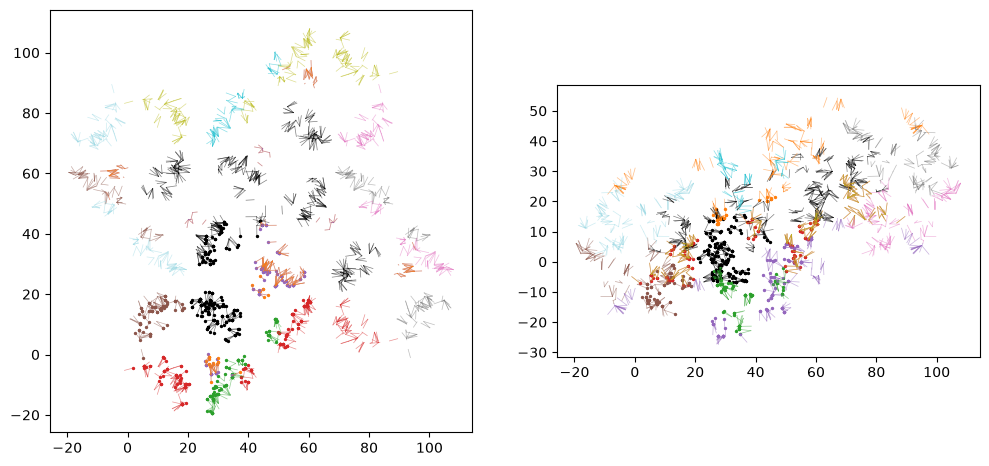

In [5]:
# plot the external contacts as lines in 2d projections.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# assign unique values of pbc_shift2 to colors
unique_pbc_shifts = external_df_expanded['pbc_shift2'].unique()
colors = plt.colormaps['tab20'].resampled(len(unique_pbc_shifts))

for row in external_df_expanded.itertuples():
    # if row.sym_idx1 != 0:
    #     continue  # only plot contacts from the reference ASU
    x1, y1, z1 = row.r1
    x2, y2, z2 = row.r2
    # color by pbc_shift1 and pbc_shift2 not 0,0,0
    color = colors(list(unique_pbc_shifts).index(row.pbc_shift2)) if row.pbc_shift2 != (0, 0, 0) else 'k'

    ax1.plot([x1, x2], [y1, y2], color=color, alpha=0.5, linewidth=.5)
    ax2.plot([x1, x2], [z1, z2], color=color, alpha=0.5, linewidth=.5)
    if row.sym_idx1 == 0:
        ax1.scatter(x1, y1, color=color, s=2)
        ax2.scatter(x1, z1, color=color, s=2)
    if (row.pbc_shift2 == (0, 0, 0)) and (row.sym_idx2 == 0):
        ax1.scatter(x2, y2, color=color, s=2)
        ax2.scatter(x2, z2, color=color, s=2)
# equal aspect
ax1.set_aspect('equal', 'box')
ax2.set_aspect('equal', 'box')

# 5. Learn how Hessian construction works for rigid bodies (TLS? Projections?)

In [6]:
# get first atom of groups[0] selection:
cra = groups[0].first_in_model(st[0])
tls_ori = st.meta.refinement[0].tls_groups[cra.atom.tls_group_id].origin
dr = cra.atom.pos - tls_ori
A = np.array([[1, 0, 0, 0, dr.z, -dr.y], [0, 1, 0, -dr.z, 0, dr.x], [0, 0, 1, dr.y, -dr.x, 0]])
group_mass_tensors = [np.zeros((6, 6)) for _ in range(len(groups))]

for group_id, selection in enumerate(groups):
    tls_ori = st.meta.refinement[0].tls_groups[group_id].origin
    for model in selection.models(st):
        for chain in selection.chains(model):
            for residue in selection.residues(chain):
                for atom in selection.atoms(residue):
                    dr = atom.pos - tls_ori
                    A = np.array([[1, 0, 0, 0, dr.z, -dr.y], [0, 1, 0, -dr.z, 0, dr.x], [0, 0, 1, dr.y, -dr.x, 0]])
                    group_mass_tensors[group_id] += atom.element.weight * atom.occ * A.T @ A

# lay out P matrix with 2*6 columns (one for each group) and N*3 rows (one for each atom)

atom_id = 0
row_indices = []
col_indices = []
values = []
for group_id, selection in enumerate(groups):
    tls_ori = st.meta.refinement[0].tls_groups[group_id].origin
    for model in selection.models(st):
        for chain in selection.chains(model):
            for residue in selection.residues(chain):
                for atom in selection.atoms(residue):
                    dr = atom.pos - tls_ori
                    row_start = atom_id*3
                    col_start = group_id*6
                    sqrt_mass = np.sqrt(atom.element.weight * atom.occ)
                    row_indices.extend([n + row_start for n in [0,1,2,0,0,1,1,2,2]])
                    col_indices.extend([n + col_start for n in [0,1,2,4,5,3,5,3,4]])
                    values.extend([v*sqrt_mass for v in [1, 1, 1, dr.z, -dr.y, -dr.z, dr.x, dr.y, -dr.x]])
                    atom_id += 1
num_atoms = atom_id
P = sparse.csr_array((values, (row_indices, col_indices)), shape=(num_atoms*3, len(groups)*6))
PP = P.T @ P
PP = PP.toarray()

In [7]:
# Incidence matrix for the ASU.
# have a look at the inter-group springs within the ASU (no symmetry info required)
asu_df = external_df[(external_df['sym_idx2']==0) & (external_df['pbc_shift2']==(0,0,0))].copy()

# create a mapping between nodes (identified by cra string) and indices in an array
cra_index_map = {}

for row in asu_df.itertuples():
    if row.cra1 not in cra_index_map:
        cra_index_map[row.cra1] = len(cra_index_map)
    if row.cra2 not in cra_index_map:
        cra_index_map[row.cra2] = len(cra_index_map)

# compute the unit vector along each edge and node position relative to tls matrix ori
asu_df['dn'] = pd.Series([None] * len(asu_df), dtype=object)
for row in asu_df.itertuples():
    cra1 = st[0].find_cra(address_from_cra_string(row.cra1))
    cra2 = st[0].find_cra(address_from_cra_string(row.cra2))
    dn = (cra2.atom.pos - cra1.atom.pos).normalized()
    asu_df.at[row.Index, 'dn'] = (dn.x, dn.y, dn.z)

row_indices = []
col_indices = []
values = []
for edge_index, row in enumerate(asu_df.itertuples()):
    dn = row.dn
    col_index_start = 3*cra_index_map[row.cra1]
    row_index_start = 3*edge_index
    row_indices.extend([row_index_start + n for n in range(3)])
    col_indices.extend([col_index_start + n for n in range(3)])
    values.extend([-1*v for v in dn])
    col_index_start = 3*cra_index_map[row.cra2]
    row_indices.extend([row_index_start + n for n in range(3)])
    col_indices.extend([col_index_start + n for n in range(3)])
    values.extend(list(dn))

E = sparse.csr_array((values, (row_indices, col_indices)), shape=(3*len(asu_df), 3*len(cra_index_map)))

In [8]:
# Hessian
# For computing this, first calculate the normal vector in ASU reference frame: R^T (r2-r1)/|r2-r1| and make sure that
# different ASU copies agree.

external_df_expanded['n1'] = pd.Series([None] * len(external_df_expanded), dtype=object)
external_df_expanded['n2'] = pd.Series([None] * len(external_df_expanded), dtype=object)

for row in external_df_expanded.itertuples():
    n = gemmi.Vec3(*row.r2) - gemmi.Vec3(*row.r1)
    n /= n.length()
    if row.sym_idx1 == 0:
        R1 = gemmi.Mat33()
    else:
        R1 = st.cell.images[row.sym_idx1 - 1].mat
    if row.sym_idx2 == 0:
        R2 = gemmi.Mat33()
    else:
        R2 = st.cell.images[row.sym_idx2 - 1].mat
    n1 = R1.transpose() @ n
    n2 = R2.transpose() @ n
    external_df_expanded.at[row.Index, 'n1'] = (n1.x, n1.y, n1.z)
    external_df_expanded.at[row.Index, 'n2'] = (n2.x, n2.y, n2.z)

In [9]:
external_df_expanded.set_index(['cra1','cra2']).sort_index()

sym_idx1  sym_idx2 pbc_shift1  pbc_shift2  \
cra1         cra2                                                        
A/ALA 129/O  A/SER 166/OG.A         0         1  (0, 0, 0)  (0, 0, -1)   
             A/SER 166/OG.A         1         2  (0, 0, 0)   (0, 0, 0)   
             A/SER 166/OG.A         2         3  (0, 0, 0)   (0, 0, 0)   
A/ALA 52/N   A/LYS 11/CD            0         1  (0, 0, 0)  (0, 0, -1)   
             A/LYS 11/CD            1         2  (0, 0, 0)   (0, 0, 0)   
...                               ...       ...        ...         ...   
B/VAL 49/CG2 B/LEU 169/C            3         2  (0, 0, 0)  (-1, 0, 0)   
             B/LEU 169/O            0         3  (0, 0, 0)  (0, -1, 0)   
             B/LEU 169/O            1         0  (0, 0, 0)   (1, 0, 1)   
             B/LEU 169/O            2         1  (0, 0, 0)   (0, 1, 0)   
             B/LEU 169/O            3         2  (0, 0, 0)  (-1, 0, 0)   

                             group_id1  group_id2  \
cra1         cra2                                   
A/ALA 129/O  A/SER 166/OG.A          0          0   
             A/SER 166/OG.A          0          0   
             A/SER 166/OG.A          0          0   
A/ALA 52/N   A/LYS 11/CD             0          0   
             A/LYS 11/CD             0          0   
...                                ...        ...   
B/VAL 49/CG2 B/LEU 169/C             1          1   
             B/LEU 169/O             1          1   
             B/LEU 169/O             1          1   
             B/LEU 169/O             1          1   
             B/LEU 169/O             1          1   

                                                                            r1  \
cra1         cra2                                                                
A/ALA 129/O  A/SER 166/OG.A                     (42.37165, 30.65365, -4.23508)   
             A/SER 166/OG.A           (57.79735, 42.37165, 25.632170000000002)   
             A/SER 166/OG.A  (46.07934999999999, 57.79735, 15.676420000000002)   
A/ALA 52/N   A/LYS 11/CD                            (51.85454, 24.05065, 4.92)   
             A/LYS 11/CD               (64.40034999999999, 51.85454, 34.78725)   
...                                                                        ...   
B/VAL 49/CG2 B/LEU 169/C                (-3.63668, 70.72945999999999, 8.51282)   
             B/LEU 169/O                        (17.72154, -3.63668, -1.44293)   
             B/LEU 169/O               (92.08767999999999, 17.72154, 28.42432)   
             B/LEU 169/O      (70.72945999999999, 92.08767999999999, 18.46857)   
             B/LEU 169/O                (-3.63668, 70.72945999999999, 8.51282)   

                                                                            r2  \
cra1         cra2                                                                
A/ALA 129/O  A/SER 166/OG.A            (44.69086999999999, 32.04797, -6.36586)   
             A/SER 166/OG.A  (56.40302999999999, 44.69086999999999, 23.5013...   
             A/SER 166/OG.A            (43.76013, 56.40302999999999, 13.54564)   
A/ALA 52/N   A/LYS 11/CD     (55.072299999999984, 25.7504, 3.5411099999999984)   
             A/LYS 11/CD     (62.700599999999994, 55.072299999999984, 33.40...   
...                                                                        ...   
B/VAL 49/CG2 B/LEU 169/C     (-4.70684, 73.99974999999999, 7.0950299999999995)   
             B/LEU 169/O     (15.284240000000002, -4.38406, -3.707000000000...   
             B/LEU 169/O              (92.83506, 15.284240000000002, 26.16025)   
             B/LEU 169/O                         (73.16676, 92.83506, 16.2045)   
             B/LEU 169/O               (-4.38406, 73.16676, 6.248749999999999)   

                                                                            n1  \
cra1         cra2                                                                
A/ALA 129/O  A/SER 166/OG.A  (0.6733521428336533, 0.4048207413681431, -0.61...

In [10]:
# compute Hessian matrix?
#
# How to handle PBC? I think with current expanded model, the springs between unit cells will be double-counted.
# Can detect this, I think, by dropping the pbc_shift columns and finding unique edges.

external_df_expanded_pbc = external_df_expanded.copy()

for row in external_df_expanded.itertuples():
    if (row.cra1, row.sym_idx1) > (row.cra2, row.sym_idx2):
        external_df_expanded_pbc.at[row.Index, 'cra1'] = row.cra2
        external_df_expanded_pbc.at[row.Index, 'sym_idx1'] = row.sym_idx2
        external_df_expanded_pbc.at[row.Index, 'pbc_shift1'] = row.pbc_shift2
        external_df_expanded_pbc.at[row.Index, 'group_id1'] = row.group_id2
        external_df_expanded_pbc.at[row.Index, 'r1'] = row.r2
        external_df_expanded_pbc.at[row.Index, 'n1'] = row.n2
        external_df_expanded_pbc.at[row.Index, 'cra2'] = row.cra1
        external_df_expanded_pbc.at[row.Index, 'sym_idx2'] = row.sym_idx1
        external_df_expanded_pbc.at[row.Index, 'pbc_shift2'] = row.pbc_shift1
        external_df_expanded_pbc.at[row.Index, 'group_id2'] = row.group_id1
        external_df_expanded_pbc.at[row.Index, 'r2'] = row.r1
        external_df_expanded_pbc.at[row.Index, 'n2'] = row.n1

external_df_expanded_pbc.drop_duplicates(subset=['cra1','cra2','sym_idx1','sym_idx2'],inplace=True)
external_df_expanded_pbc

,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2,r1,r2,n1,n2
0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)","(-0.6843666236758299, 0.7279667902534173, 0.04...","(-0.7279667902534173, -0.6843666236758299, 0.0..."
1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)","(-0.6724555449669695, 0.7401304577269437, 0.00...","(-0.7401304577269437, -0.6724555449669695, 0.0..."
2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)","(-0.7895759269938094, 0.5454657170161752, 0.28...","(-0.5454657170161752, -0.7895759269938094, 0.2..."
3,A/PHE 156/CZ,A/TYR 9/C,3,0,"(0, 0, 0)","(0, 0, 0)",0,0,"(33.5479, 38.297419999999995, 15.76611)","(33.53765, 35.06444, 13.83823)","(-0.8588822583114761, 0.0027230428730434316, 0...","(0.0027230428730434316, 0.8588822583114761, 0...."
4,A/PHE 156/CE2,A/TYR 9/O,3,0,"(0, 0, 0)","(0, 0, 0)",0,0,"(34.09091, 38.94922, 14.69258)","(32.68961, 35.29065, 14.70957)","(-0.933835559897385, 0.3576762970461698, -0.00...","(0.3576762970461698, 0.933835559897385, -0.004..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1978,B/ASN 4/O,B/TYR 42/OH.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(0.10113000000000001, 61.87219999999999, -8.78...","(-0.9083000000000001, 61.58114, -12.4373400000...","(0.07658456551600085, -0.26560419833992366, -0...","(0.07658456551600085, -0.26560419833992366, -0..."
1979,B/SER 5/CA.B,B/TYR 42/OH.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(-2.25059, 62.814809999999994, -9.76083)","(-0.9083000000000001, 61.58114, -12.4373400000...","(0.38094763875995763, 0.4144886444763226, -0.8...","(0.38094763875995763, 0.4144886444763226, -0.8..."
1980,B/SER 5/CB.B,B/TYR 42/CE2.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-2.07505, 62.62223, -14.22047)","(-0.04216339401839544, 0.36239016963377046, -0...","(-0.04216339401839544, 0.36239016963377046, -0..."
1981,B/SER 5/CB.B,B/TYR 42/CZ.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-1.64307, 61.47500999999999, -13.60131)","(0.2631264288238382, 0.5014556447410168, -0.82...","(0.2631264288238382, 0.5014556447410168, -0.82..."


In [11]:
# number of groups in the unit cell
tls_groups = st.meta.refinement[0].tls_groups
ngroups = (1 + len(st.cell.images))*len(tls_groups)
nedges = len(external_df_expanded_pbc)

row_indices = []
col_indices = []
values = []

for edge_index, row in enumerate(external_df_expanded_pbc.itertuples()):
    row_start = edge_index*3
    col_start1 = row.sym_idx1*6 + len(tls_groups)*row.sym_idx1
    col_start2 = row.sym_idx2*6 + len(tls_groups)*row.sym_idx2
    dr1 = gemmi.Position(*row.r1) - tls_groups[row.group_id1].origin
    dr2 = gemmi.Position(*row.r2) - tls_groups[row.group_id2].origin
    row_indices.extend([n + row_start for n in [0,1,2,0,0,1,1,2,2]])
    col_indices.extend([n + col_start1 for n in [0,1,2,4,5,3,5,3,4]])
    values.extend([-1*v for v in [1, 1, 1, dr1.z, -dr1.y, -dr1.z, dr1.x, dr1.y, -dr1.x]])
    row_indices.extend([n + row_start for n in [0,1,2,0,0,1,1,2,2]])
    col_indices.extend([n + col_start2 for n in [0,1,2,4,5,3,5,3,4]])
    values.extend([1, 1, 1, dr2.z, -dr2.y, -dr2.z, dr2.x, dr2.y, -dr2.x])

P = sparse.csr_array((values, (row_indices, col_indices)), shape=(nedges*3, ngroups*6))
P


<Compressed Sparse Row sparse array of dtype 'float64'
	with 21132 stored elements and shape (4200, 48)>

In [12]:
gemmi.Position(*row.r1)

<gemmi.Position(-3.511, 62.4552, -10.5311)>